<a href="https://colab.research.google.com/github/lewinskie254/timeseries-youtube/blob/main/Lecture_3_Timeseries_Analysis_MovingAverage.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
from statsmodels.tsa.stattools import adfuller
import pandas as pd
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt


In [39]:
df = pd.read_csv("https://raw.githubusercontent.com/marcopeix/TimeSeriesForecastingInPython/master/data/widget_sales.csv")

In [40]:
df.head()

,widget_sales
0,50.496714
1,50.805493
2,51.477758
3,53.542228
4,54.873108


<Axes: >

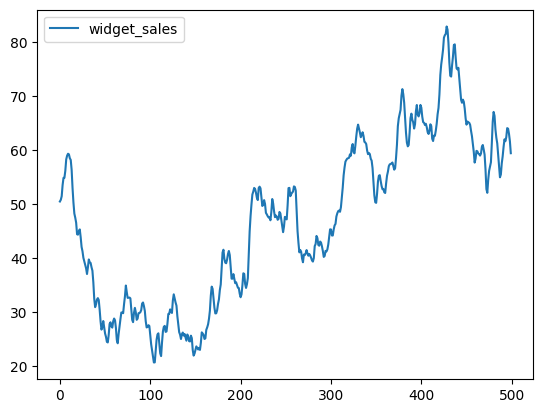

In [41]:
df.plot()

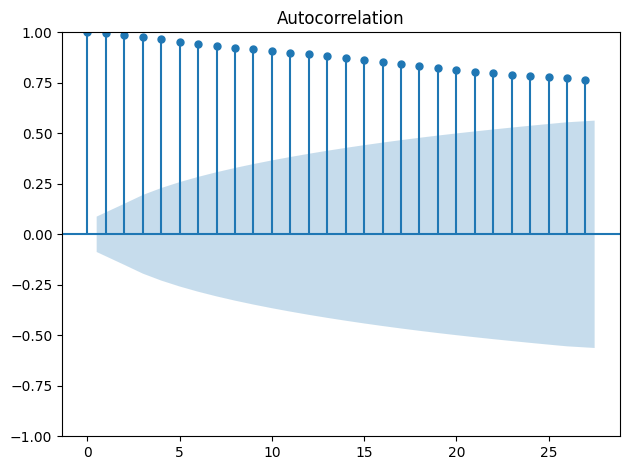

In [42]:
plot_acf(df)
plt.tight_layout()


In [43]:
#get the ADF statsistic
results = adfuller(df)
print(f"ADF Statistic: {results[0]}")
print(f"p-value: {results[1]}")

ADF Statistic: -1.5121662069359048
p-value: 0.5274845352272605


/tmp/ipykernel_4226/4167691710.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  results = adfuller(df)


In [44]:
#get the diff
df_diff = df.diff()

<Axes: >

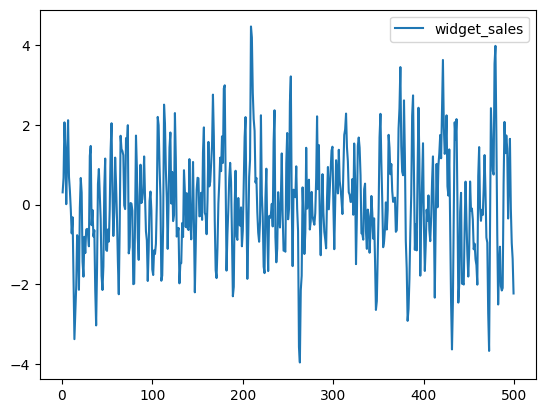

In [45]:
#plot diff
df_diff.plot()

In [46]:
#get adf statsistic on the diff
results = adfuller(df_diff[1:])
print(f"ADF Statistic: {results[0]}")
print(f"p-value: {results[1]}")

ADF Statistic: -10.576657780341959
p-value: 7.076922818587193e-19


/tmp/ipykernel_4226/3835449154.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  results = adfuller(df_diff[1:])


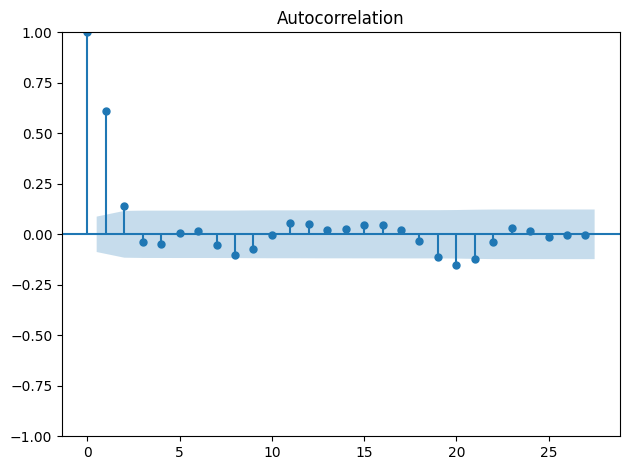

In [47]:
plot_acf(df_diff[1:])
plt.tight_layout()

In [48]:
from statsmodels.tsa.statespace.sarimax import SARIMAX


def rolling_forecast(df: pd.DataFrame, train_len: int, horizon: int,window: int, method: str, q: int) -> list:
  #horizon is the total number of steps we want to predict
  total_len = train_len + horizon

  #here we use a naive prediction method, where we use the last timestep's value as this timesteps prediction
  #e.g. if the stock price yesterday closed at $25, we predict that it will close at $25 today
  if method == 'last':
    #here we populate all the predictions made for all timesteps for the horizon we are predicting
    pred_last_value = []

    # We forecast the future in batches of `window` timesteps.
    # For example, with window=3, each iteration generates
    # predictions for the next 3 timesteps.
    for i in range(train_len, total_len, window):
      # we always use the previous value as the predicted value for the current timestep in this method
      last_value = df[:i].iloc[-1].values[0]
      #if we are using a window of 3, the next 3 values will be equal to the last timestep's value etc
      pred_last_value.extend(last_value for _ in range(window))
      #if the method == last, we return the populated list of prediction
    return pred_last_value

    # Forecast the horizon in batches of `window` timesteps.
  elif method == 'MA':
      #populate the predictions
      pred_MA = []

      #same case for the window up to the horizon
      for i in range(train_len, total_len, window):

        # SARIMAX order is (p, d, q).
        # Here p=0, d=0, and q is the MA order.
        model = SARIMAX(df[:i], order=(0,0,q))
        #fit the model
        res = model.fit(disp=False)

        # Generate predictions through the end of the current forecast window.
        # The end index is inclusive, hence the `-1`.
        predictions = res.get_prediction(0, i + window - 1)

        # Select only the last `window` predictions, which correspond to
        # the out-of-sample forecasts for the next `window` timesteps.
        #Out-of-Sample (OOS) simply refers to Predictions for data that the model did not have available when it was trained.
        oos_pred = predictions.predicted_mean.iloc[-window:]
        pred_MA.extend(oos_pred)
      return pred_MA

In [49]:
#Take 80% of the data as the train data and 20% as the test data

train = df_diff[:int(len(df_diff)* 0.8)]
test = df_diff[int(len(df_diff)* 0.8):]
len(train), len(test)

(400, 100)

In [50]:

#lets make a copy of the test data to evaluate how well our model is doing
pred_df = test.copy()

#set the details for the model, we will make predictions in batches of 2 (window)
TRAIN_LEN = len(train)
HORIZON = len(test)
WINDOW = 2
Q = 2 #MA(q), where our Q from the ACF plot is 2

pred_last_value = rolling_forecast(df_diff, TRAIN_LEN, HORIZON, WINDOW,'last', Q)
pred_MA = rolling_forecast(df_diff, TRAIN_LEN, HORIZON, WINDOW, 'MA', Q)

In [51]:
pred_df['pred_last_value'] = pred_last_value
pred_df['pred_MA'] = pred_MA
pred_df.head()

,widget_sales,pred_last_value,pred_MA
400,-0.514755,1.540892,1.080784
401,-1.663015,1.540892,0.304014
402,-1.012522,-1.663015,-0.902671
403,-0.128113,-1.663015,-0.147446
404,-0.406210,-0.128113,0.068265


In [52]:
from sklearn.metrics import mean_squared_error

mse_last = mean_squared_error(pred_df['widget_sales'],pred_df['pred_last_value'])
mse_MA = mean_squared_error(pred_df['widget_sales'],pred_df['pred_MA'])
print(mse_last, mse_MA)

2.9437761372198112 1.8221984651167644


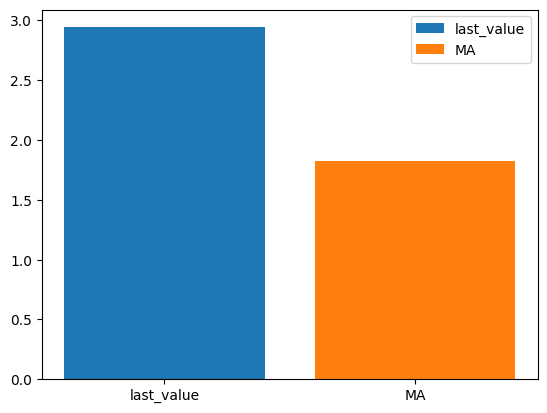

In [53]:
#plot the metrics

plt.bar('last_value', mse_last, label='last_value')
plt.bar('MA', mse_MA, label='MA')
plt.legend()

In [54]:
#create a new dataframe for the series
df['pred_widget_sales'] = pd.Series()

#To integrate the differenced data, we simply just cumulative sum from the last item in the train set
df.loc[TRAIN_LEN:, 'pred_widget_sales'] = (df['widget_sales'].iloc[TRAIN_LEN]+ pred_df['pred_MA'].cumsum())

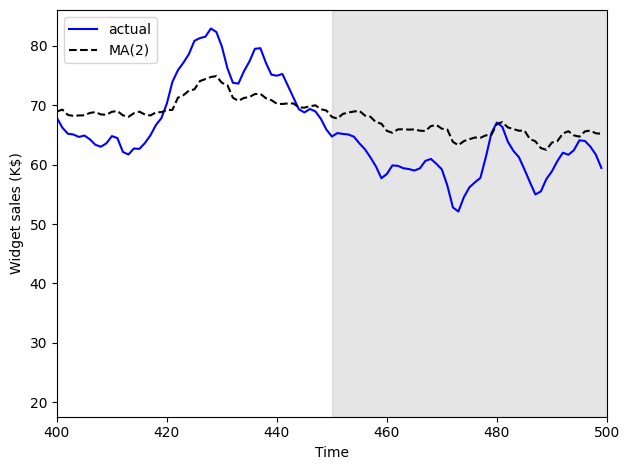

In [56]:
fig, ax = plt.subplots()
ax.plot(df['widget_sales'], 'b-', label='actual')
ax.plot(df['pred_widget_sales'], 'k--', label='MA(2)')
ax.legend(loc=2)
ax.set_xlabel('Time')
ax.set_ylabel('Widget sales (K$)')
ax.axvspan(450, 500, color='#808080', alpha=0.2)

ax.set_xlim(400, 500)
plt.tight_layout()